### 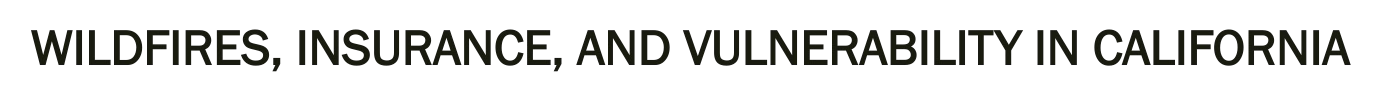

### Yujin Hazel Lee
### CRP 5680 Week 7 Discussion

<div style="display: flex; align-items: center;">
    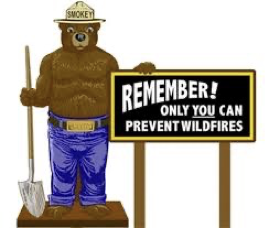
    <div>
        <h3><br><br><br>Wildfires and Insurance</h3>
        <p>
        Between 2018–2021, insurer-initiated non-renewals disproportionately affected
        certain California zip codes. <br>This project examines how socioeconomic and
        demographic characteristics mediate wildfire exposure and insurance vulnerability.
        </p>
    </div>
</div>


## Research Questions

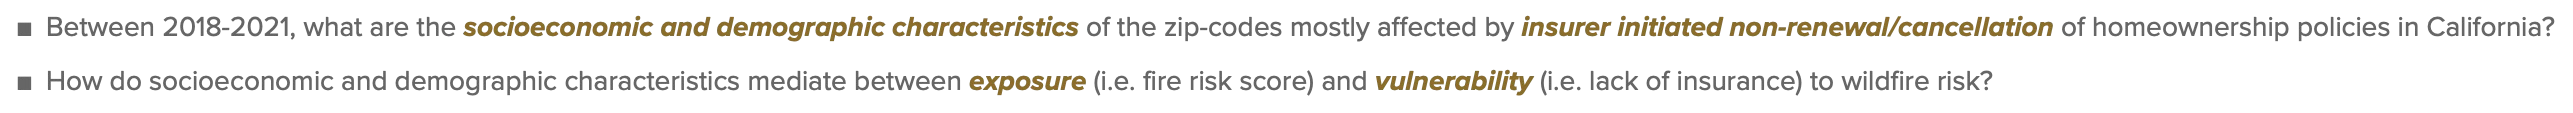

## DATA 
- Merged Data Set - transformed into a geodata 

In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
import os 
import contextily as ctx
import statsmodels.formula.api as smf

In [2]:
wildfire = gpd.read_file('/Users/yujinlee/Documents/Fall 2024/Research/Wildfire/stata_20241125')

In [3]:
wildfire.head()

,v1,zipcode,year,shape_area,clip_prop,avgppc_ho,numberofne,numberoflo,numberofmo,numberofhi,...,sqm2,avg_whp_co,delta_afr,PO_NAME_1,STATE_1,POPULATI_1,POP_SQMI_1,SQMI_1,zipcdoe,geometry
0,1538,90001,2018,NaN,0.0,2.16,742.0,49.0,0.0,0.0,...,0.099358,0.0,NaN,Los Angeles,CA,59907,16970.82,3.53,90001,"POLYGON ((532456.173 7660538.07, 533148.797 76..."
1,1729,90001,2019,NaN,0.0,1.79,828.0,50.0,0.0,0.0,...,0.099358,0.0,0.655145,Los Angeles,CA,59907,16970.82,3.53,90001,"POLYGON ((532456.173 7660538.07, 533148.797 76..."
2,2012,90001,2020,NaN,0.0,NaN,884.0,407.0,0.0,0.0,...,0.099358,0.0,730.783080,Los Angeles,CA,59907,16970.82,3.53,90001,"POLYGON ((532456.173 7660538.07, 533148.797 76..."
3,2304,90001,2021,NaN,0.0,NaN,875.0,469.0,0.0,1.0,...,0.099358,0.0,15.495818,Los Angeles,CA,59907,16970.82,3.53,90001,"POLYGON ((532456.173 7660538.07, 533148.797 76..."
4,1624,90002,2018,NaN,0.0,1.51,1054.0,60.0,0.0,7.0,...,0.087255,0.0,NaN,Los Angeles,CA,53573,17281.61,3.10,90002,"POLYGON ((536465.606 7649213.814, 537064.829 7..."


In [4]:
print(list(wildfire.columns))

['v1', 'zipcode', 'year', 'shape_area', 'clip_prop', 'avgppc_ho', 'numberofne', 'numberoflo', 'numberofmo', 'numberofhi', 'numberofve', 'earnedprem', 'earnedexpo', 'noncatcova', 'noncatco_1', 'noncatco_2', 'noncatco_3', 'noncatcovc', 'noncatco_4', 'noncatco_5', 'noncatco_6', 'catcovafir', 'catcovaf_1', 'catcovasmo', 'catcovas_1', 'catcovcfir', 'catcovcf_1', 'catcovcsmo', 'catcovcs_1', 'missing_co', 'avgppc_do', 'numberof_1', 'numberof_2', 'numberof_3', 'numberof_4', 'numberof_5', 'earnedpr_1', 'earnedex_1', 'noncatco_7', 'noncatco_8', 'noncatco_9', 'noncatco10', 'noncatco11', 'noncatco12', 'noncatco13', 'noncatco14', 'catcovaf_2', 'catcovaf_3', 'catcovas_2', 'catcovas_3', 'catcovcf_2', 'catcovcf_3', 'catcovcs_2', 'catcovcs_3', 'avgppc_dt', 'numberof_6', 'numberof_7', 'numberof_8', 'numberof_9', 'numberof10', 'earnedpr_2', 'earnedex_2', 'noncatco15', 'noncatco16', 'noncatco17', 'noncatco18', 'noncatco19', 'noncatco20', 'noncatco21', 'noncatco22', 'catcovaf_4', 'catcovaf_5', 'catcovas_4'

<Axes: >

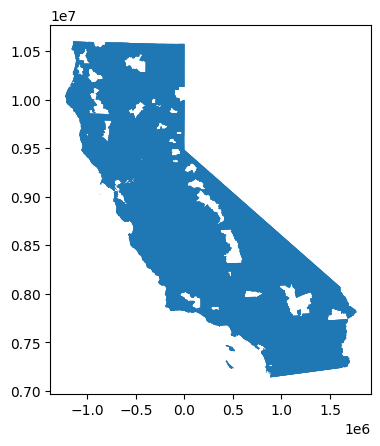

In [5]:
wildfire.plot()

### Remember our Equation of Interest?

$$
\mathbf{Y}_i =
\boldsymbol{\beta_0}
+ \boldsymbol{\beta_1} \mathbf{AvgFireRisk}_i
+ \boldsymbol{\beta_2} \mathbf{SocioeconomicVars}_i
+ \boldsymbol{\beta_3} \mathbf{Moratorium}_i
+ \boldsymbol{\beta_4} \mathbf{NaturalDisasterRisk}_i
+ \boldsymbol{\beta_5} \mathbf{CrimeRates}_i
+ \boldsymbol{\beta_6} \mathbf{SpatialLag(AvgFireRisk)}_i
+ \boldsymbol{\varepsilon}_i
$$

- 'insurerini' - insurer initiated cancellations
- 'avgfireris' - average fire risk
- 'ln_med_hh_', ''med_hh_inc' - logged median hh income and hh median income
- 'median_age' - median age
- 'total_pop' - total population ('prop_white', 'prop_amind', 'prop_asian', 'prop_black', 'prop_other', 'prop_twoor', 'prop_nativ', 'prop_latin')
- 'tot_policy', 'ln_tot_pol' - total policies     
- 'tot_househ' - total households
- 'moratorium' - moratorium
- 'lifted_mor' - lifted moratorium 

- 'year'
- 'zipcode' 

In [6]:
## What are some variables that you would be interested in looking at? 
## Write out some descriptive/univariate statistics

wildfire.insurerini.describe()

count    6552.000000
mean      125.922619
std       147.334230
min         0.000000
25%        24.000000
50%        85.000000
75%       173.000000
max      1562.000000
Name: insurerini, dtype: float64

<Axes: >

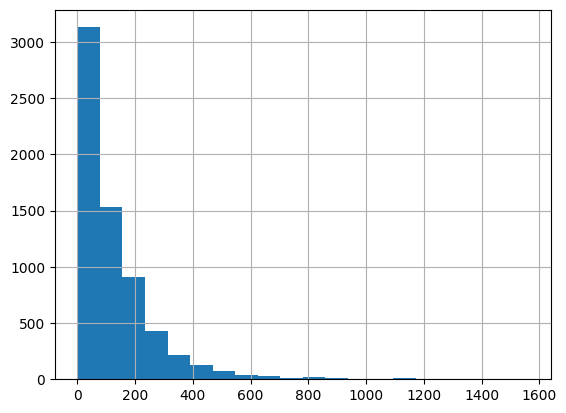

In [7]:
wildfire.insurerini.hist(bins =20)

In [8]:
wildfire['avgfireris'].describe()

count    6552.000000
mean        0.940082
std         0.889057
min         0.000000
25%         0.270406
50%         0.531012
75%         1.495011
max         3.500000
Name: avgfireris, dtype: float64

<Axes: >

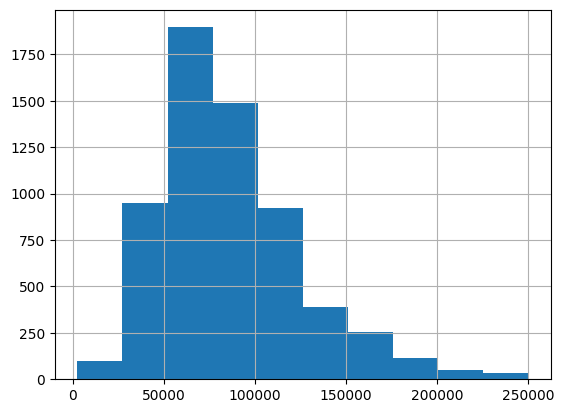

In [9]:
wildfire['med_hh_inc'].hist()

<Axes: >

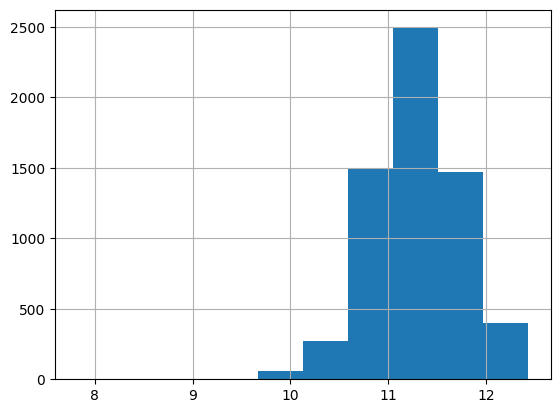

In [10]:
np.log(wildfire['med_hh_inc']).hist()

In [11]:
## VIF Statistics
lm_vif = smf.ols(formula = 'insurerini ~ avgfireris + ln_med_hh_ + median_age + prop_amind + prop_asian + prop_black + \
prop_other + prop_twoor + prop_nativ + prop_latin', data = wildfire).fit()

In [12]:
print("VIF for livingArea is ", 1/(1-lm_vif.rsquared))

VIF for livingArea is  1.0900298490713964


In [13]:
## Correlation statistics into a heat map?
## Do we have any variables of concern?

wildfire[['avgfireris', 'ln_med_hh_', 'median_age', 'prop_amind', 'prop_asian', 'prop_black', 'prop_other',\
          'prop_twoor', 'prop_nativ', 'prop_latin', 'insurerini']].corr()

,avgfireris,ln_med_hh_,median_age,prop_amind,prop_asian,prop_black,prop_other,prop_twoor,prop_nativ,prop_latin,insurerini
avgfireris,1.000000,-0.043629,0.554729,0.195522,-0.340150,-0.305563,0.020867,0.057713,-0.132204,-0.501107,-0.117661
ln_med_hh_,-0.043629,1.000000,0.078495,-0.171274,0.398513,-0.118130,0.050210,0.150846,0.066866,-0.347581,0.095162
median_age,0.554729,0.078495,1.000000,0.067754,-0.156208,-0.260364,-0.011824,-0.011646,-0.128205,-0.555145,-0.196191
prop_amind,0.195522,-0.171274,0.067754,1.000000,-0.111611,-0.072447,-0.006736,0.049083,0.003108,-0.122963,-0.104769
prop_asian,-0.340150,0.398513,-0.156208,-0.111611,1.000000,0.076198,-0.004599,0.038541,0.160883,-0.141626,0.028793
prop_black,-0.305563,-0.118130,-0.260364,-0.072447,0.076198,1.000000,0.004859,0.040380,0.143308,0.132322,0.123013
prop_other,0.020867,0.050210,-0.011824,-0.006736,-0.004599,0.004859,1.000000,-0.018338,-0.008507,-0.046886,-0.020378
prop_twoor,0.057713,0.150846,-0.011646,0.049083,0.038541,0.040380,-0.018338,1.000000,0.136367,-0.281993,-0.037681
prop_nativ,-0.132204,0.066866,-0.128205,0.003108,0.160883,0.143308,-0.008507,0.136367,1.000000,-0.016696,0.025616
prop_latin,-0.501107,-0.347581,-0.555145,-0.122963,-0.141626,0.132322,-0.046886,-0.281993,-0.016696,1.000000,0.180111


## Running Regressions 

In [14]:
import warnings 
warnings.filterwarnings("ignore")

In [15]:
## Start from the nested model (the most simple model)

In [16]:
## How does the regression differ if we just run a normal OLS regression?

ols_nest = smf.ols(formula = 'insurerini ~ avgfireris', data = wildfire).fit()

In [17]:
ols_nest.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             insurerini   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     91.85
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           1.29e-21
Time:                        20:22:23   Log-Likelihood:                -41919.
No. Observations:                6545   AIC:                         8.384e+04
Df Residuals:                    6543   BIC:                         8.386e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    144.4109      2.634     54.819      0.000     139.247     149.575
avgfireris   -19.5029      2.035     -9.584      0.000     -23.492     -15.514
==============================================================================
Omnibus:                     4362.761   Durbin-Watson:                   0.682
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            68504.515
Skew:                           3.006   Prob(JB):                         0.00
Kurtosis:                      17.665   Cond. No.                         2.63
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
## What kind of variable is our dependent (y) variable?
## What is the type of regression we should run?

negbi_nest = smf.negativebinomial(
    formula='insurerini ~ avgfireris',
    data=wildfire,
    offset=wildfire['ln_tot_pol']
).fit()

Optimization terminated successfully.
         Current function value: 4.804794
         Iterations: 9
         Function evaluations: 11
         Gradient evaluations: 11


In [19]:
negbi_nest.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:             insurerini   No. Observations:                 6536
Model:               NegativeBinomial   Df Residuals:                     6534
Method:                           MLE   Df Model:                            1
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                 0.05268
Time:                        20:22:24   Log-Likelihood:                -31404.
converged:                       True   LL-Null:                       -33150.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.0083      0.009   -452.941      0.000      -4.026      -3.991
avgfireris     0.4547      0.007     65.174      0.000       0.441       0.468
alpha          0.2107      0.004     51.253      0.000       0.203       0.219
==============================================================================
"""

In [20]:
np.exp(0.4547)

np.float64(1.575700601939791)

In [21]:
## How would you interpret the results?

## A 1 unit increase in the Average Fire Risk score, on average, will multiply the incidence risk ratio 
## of proportion of insurer-initiated cancellations by 1.58 
 

In [22]:
## Move on to the saturated model (add in more independent + control variables)

In [23]:
ols_sat = smf.ols(formula = 'insurerini ~ avgfireris + ln_med_hh_ + median_age + prop_amind + prop_asian + prop_black + \
prop_other + prop_twoor + prop_nativ + prop_latin', data = wildfire).fit()

In [24]:
ols_sat.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             insurerini   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     55.72
Date:                Tue, 10 Mar 2026   Prob (F-statistic):          2.54e-108
Time:                        20:22:24   Log-Likelihood:                -39540.
No. Observations:                6200   AIC:                         7.910e+04
Df Residuals:                    6189   BIC:                         7.918e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -545.0001     58.510     -9.315      0.000    -659.699    -430.301
avgfireris    25.8937      3.042      8.513      0.000      19.931      31.856
ln_med_hh_    62.8185      4.810     13.059      0.000      53.389      72.248
median_age    -2.2398      0.290     -7.729      0.000      -2.808      -1.672
prop_amind  -258.8288     52.577     -4.923      0.000    -361.897    -155.760
prop_asian   -18.6456     16.507     -1.130      0.259     -51.005      13.714
prop_black   257.4610     30.317      8.492      0.000     198.029     316.893
prop_other  -375.7303    244.666     -1.536      0.125    -855.361     103.900
prop_twoor   -80.0803     60.258     -1.329      0.184    -198.208      38.047
prop_nativ   166.7939    332.465      0.502      0.616    -484.953     818.541
prop_latin   114.1455     12.375      9.224      0.000      89.886     138.405
==============================================================================
Omnibus:                     3999.286   Durbin-Watson:                   0.736
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            62013.297
Skew:                           2.870   Prob(JB):                         0.00
Kurtosis:                      17.391   Cond. No.                     8.00e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large,  8e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [25]:
## Negative Binomial Regression?

negbi_sat = smf.negativebinomial(formula='insurerini ~ avgfireris + ln_med_hh_ + median_age + prop_amind + prop_asian + prop_black + \
prop_other + prop_twoor + prop_nativ + prop_latin', 
                              data = wildfire,
                             offset = wildfire['ln_tot_pol']).fit()

         Current function value: 4.799425
         Iterations: 35
         Function evaluations: 43
         Gradient evaluations: 43


In [26]:
negbi_sat.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:             insurerini   No. Observations:                 6194
Model:               NegativeBinomial   Df Residuals:                     6183
Method:                           MLE   Df Model:                           10
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                 0.07682
Time:                        20:22:24   Log-Likelihood:                -29728.
converged:                      False   LL-Null:                       -32201.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.1067      0.186     -5.935      0.000      -1.472      -0.741
avgfireris     0.5479      0.009     57.903      0.000       0.529       0.566
ln_med_hh_    -0.2632      0.015    -17.123      0.000      -0.293      -0.233
median_age    -0.0034      0.001     -3.578      0.000      -0.005      -0.002
prop_amind     0.3179      0.187      1.699      0.089      -0.049       0.685
prop_asian    -0.3908      0.049     -8.019      0.000      -0.486      -0.295
prop_black     0.5543      0.092      5.996      0.000       0.373       0.736
prop_other    -4.7902      0.779     -6.152      0.000      -6.316      -3.264
prop_twoor    -0.1550      0.207     -0.749      0.454      -0.561       0.251
prop_nativ    -4.6949      1.049     -4.476      0.000      -6.751      -2.639
prop_latin     0.4856      0.040     12.278      0.000       0.408       0.563
alpha          0.1532      0.003     48.712      0.000       0.147       0.159
==============================================================================
"""

In [27]:
np.exp(0.5479)

np.float64(1.7296170056789062)

In [28]:
## How would you interpret the results?

## A 1 unit increase in the Average Fire Risk score, on average, will multiply the incidence risk ratio 
## of proportion of insurer-initiated cancellations by 1.73, controlling for household income and race


### Interaction Terms 

In [29]:
## Try creating an interaction term of your choice 

### Spatial Autocorrelation

In [30]:
!pip install libpysal esda splot pysal

In [31]:
from libpysal.weights import Queen
from esda.moran import Moran
from splot.esda import plot_moran
from pysal.viz import splot
from pysal.lib import weights
from numpy.random import seed
import esda
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [69]:
wildfire = wildfire.dropna(subset ='avgfireris')
wildfire_2020 = wildfire[wildfire['year'] == 2020].reset_index()

In [70]:
## making knn =8 weights 

w8 = weights.KNN.from_dataframe(wildfire_2020, k=8)
w8.transform = "R"
#w8.set_transform("R")

In [71]:
## create new column for spatial lag for avgfireris

wildfire_2020['afr_lag'] = weights.spatial_lag.lag_spatial(
    w8, wildfire_2020['avgfireris']
)

In [72]:
wildfire_2020[['avgfireris', 'afr_lag']].head()

,avgfireris,afr_lag
0,0.132506,0.161502
1,0.164933,0.184650
2,0.147452,0.169716
3,0.312436,0.269694
4,0.303030,0.258625


In [73]:
moran = esda.moran.Moran(wildfire_2020['avgfireris'], w8)
print(moran.I)
print(moran.p_sim)

0.739259164771551
0.001


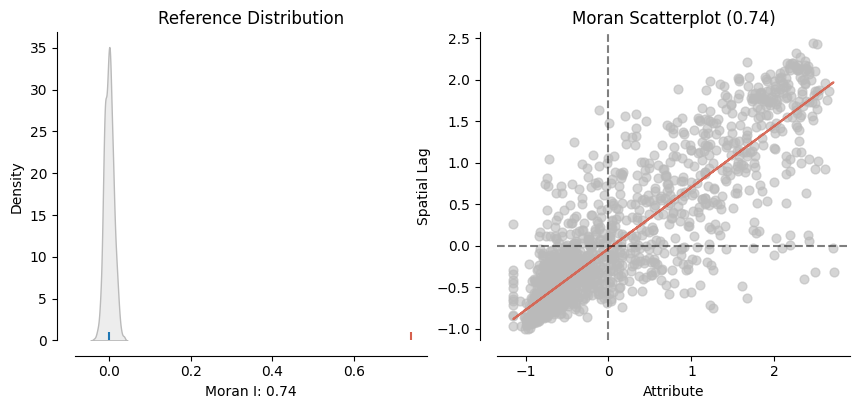

In [74]:
plot_moran(moran);

In [92]:
## How do we derive the Moran's I value of 0.74?
## Calculate the standardized mean of both the fire risk and lagged fire risk 

wildfire_2020["avgfireris_std"] = (wildfire_2020["avgfireris"] - wildfire_2020["avgfireris"].mean())/wildfire_2020["avgfireris"].std()
wildfire_2020["afr_lag_std"] = (wildfire_2020["afr_lag"] - wildfire_2020["afr_lag"].mean())/wildfire_2020["afr_lag"].std()

In [96]:
## find the coefficient for the regression

equation = smf.ols(formula = 'afr_lag_std ~ avgfireris_std',
                   data = wildfire_2020).fit()

In [97]:
equation.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            afr_lag_std   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     5080.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:09:24   Log-Likelihood:                -1167.1
No. Observations:                1638   AIC:                             2338.
Df Residuals:                    1636   BIC:                             2349.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       5.551e-17      0.012   4.55e-15      1.000      -0.024       0.024
avgfireris_std     0.8697      0.012     71.272      0.000       0.846       0.894
==============================================================================
Omnibus:                      147.110   Durbin-Watson:                   1.648
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              877.142
Skew:                          -0.141   Prob(JB):                    3.40e-191
Kurtosis:                       6.574   Cond. No.                         1.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [130]:
## the values may be a bit off because of the order of calculation. Whereas Moran's I calculates the standardized
## values and then adds the weights, our regression adds the weights and then standardizes it 

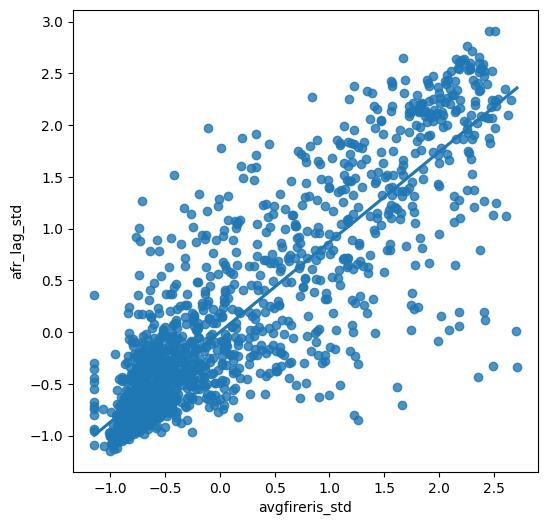

In [98]:
# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot values
sns.regplot(
    x="avgfireris_std", y="afr_lag_std", data=wildfire_2020, ci=None
);

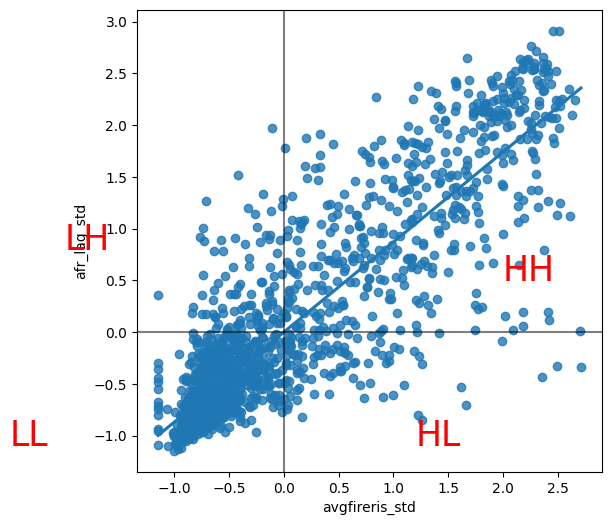

In [99]:
# Setup the figure and axis
f, ax = plt.subplots(1, figsize=(6, 6))
# Plot values
sns.regplot(x="avgfireris_std", y="afr_lag_std", data=wildfire_2020, ci=None)

# Add vertical and horizontal lines
plt.axvline(0, c="k", alpha=0.5)
plt.axhline(0, c="k", alpha=0.5)

# Add text labels for each quadrant
plt.text(2.0, .5, "HH", fontsize=25, c="r")
plt.text(1.2, -1.1, "HL", fontsize=25, c="r")
plt.text(-2.0, .8, "LH", fontsize=25, c="r")
plt.text(-2.5, -1.1, "LL", fontsize=25, c="r")
# Display
plt.show()

In [100]:
from splot import esda as esdaplot

In [64]:
lisa = esda.moran.Moran_Local(wildfire_2020['avgfireris'], w8)

In [65]:
# count the numbers of HH, LL, HL, and LH
counts = pd.value_counts(lisa.q)
counts

3    979
1    454
4    115
2     90
Name: count, dtype: int64

The result shows that the low-low (3), high-high (1) values are predominant. 
Care must be taken, however, in the interpretation of these first two maps, as the underlying **statistical significance of the local values has not been considered**. We have simply mapped the raw LISA value alongside the quadrant in which the local statistic resides. 

To statistical significance, the bottom left map distinguishes those polygons whose pseudo p-value is above (_"Non-Significant"_) or below (_"Significant"_) the threshold value of 5% we use in this context. An examination of the map suggests that quite a few local authorities have local statistics that are small enough so as to be compatible with pure chance. 

**Therefore, in order to focus on the areas that are most promising, we need to include significance information alongside the quadrant and local statistic.** Together, this "cluster map" (as it is usually called) extracts significant observations -those that are highly unlikely to have come from pure chance- and plots them with a specific color depending on their quadrant category. All of the needed pieces are contained inside the `lisa` object we have created above and, if passed in tandem with the geo-table containing the geographies it relates to, `splot` will make a cluster map for us.

Reading the clustermap reveals a few interesting aspects that would have been hard to grasp by looking at the other maps only and that are arguably more relevant for an analysis of the data. First, **fewer than half of polygons that have degrees of local spatial association strong enough to reject the idea of pure chance**:

In [66]:
print((lisa.p_sim < 0.05).sum() / len(lisa.p_sim) * 100)

59.89010989010989


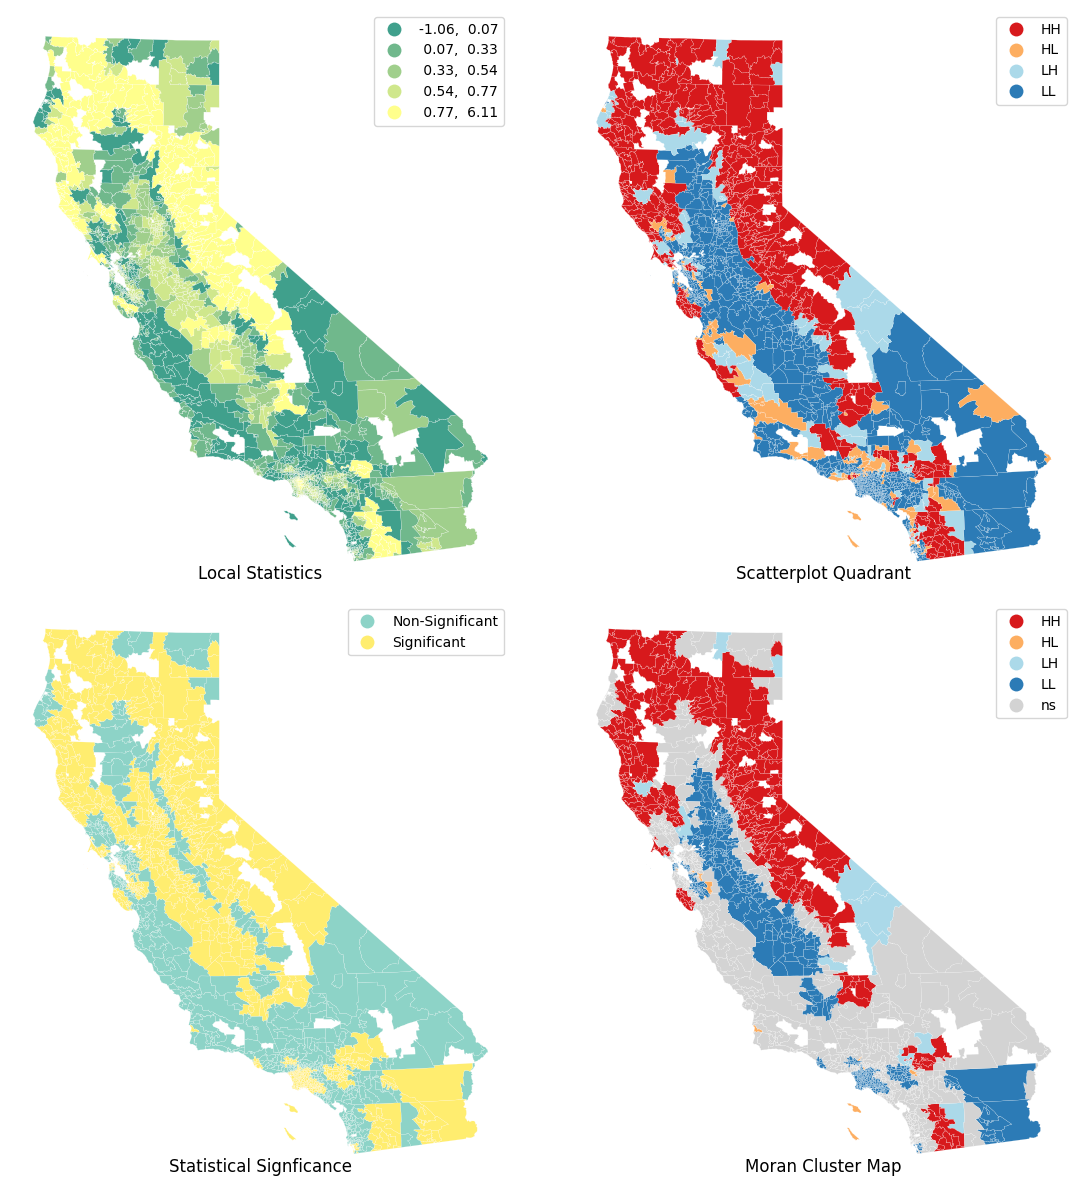

In [129]:
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
axs = axs.flatten()

## normally axs[0,0]
ax = axs[0]
wildfire_2020.assign(
    Is = lisa.Is).plot(
        column = 'Is',
        cmap = 'summer',
        scheme ='quantiles',
        k=5,
        edgecolor = 'white',
        linewidth = 0.2,
        alpha = 0.75,
        legend = True, 
        ax=ax
    )
ax.set_axis_off()

## normaly axs[0,1]
ax=axs[1]
esdaplot.lisa_cluster(lisa, wildfire_2020, p=1, ax=ax)

## normally axs[1,0]
ax=axs[2]
labels = pd.Series(
    1 * (lisa.p_sim < 0.05),
    index = wildfire_2020.index).map({1: "Significant", 0: "Non-Significant"})
wildfire_2020.assign(
    cl = labels).plot(
    column = "cl",
    categorical = True,
    k=2,
    cmap = "Set3",
    linewidth = 0.1,
    edgecolor = 'white',
    legend = True,
    ax=ax
)
ax.set_axis_off()

## normally axs[1,1]
ax=axs[3]
esdaplot.lisa_cluster(lisa, 
                      wildfire_2020, 
                      p=0.05, 
                      ax=ax)

axs[0].set_title('Local Statistics', y=0)
axs[1].set_title('Scatterplot Quadrant', y=0)
axs[2].set_title('Statistical Signficance', y=0)
axs[3].set_title('Moran Cluster Map', y=0)

f.tight_layout()
plt.show()